<a href="https://colab.research.google.com/github/avyue/datasci112_finalproject/blob/main/clean_LAHSA_homelessness_count.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install geopandas pyogrio 2>/dev/null

import io, requests
import numpy as np
import pandas as pd
import plotly.express as px                                   # grammar of graphics (L5)
import geopandas as gpd                                       # shapefiles / geospatial (Wk 9)
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # encoding (L7), distances (L6)
from sklearn.cluster import KMeans                            # unsupervised learning (L16)

pd.set_option("display.max_columns", 120)

In [ ]:
DATA_URL = ("https://www.lahsa.org/item.ashx?"
            "id=9559-hc25-data-by-census-subtract-revised-october-2025.xlsx&dl=true")

resp = requests.get(DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()
xls = pd.ExcelFile(io.BytesIO(resp.content))     # re-readable handle to all sheets
print("Sheets in workbook:", xls.sheet_names)

Sheets in workbook: ['READ ME', 'Counts', 'Variable Labels']


In [ ]:
SHEET = "Counts"
df = pd.read_excel(xls, sheet_name=SHEET, header=0)
df.columns = df.columns.astype(str).str.strip()
print("shape:", df.shape)
df.head(3)

shape: (3567, 47)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,Tract_Split,Year,City,LACity,Community_Name,SPA,sd,cd,ca_ssd,ca_sad,us_cd,totStreetSingAdult,totStreetFamHH,totStreetFamMem,totSafeParkSingAdult,totSafeParkFamHH,totSafeParkFamMem,totCars,totVans,totCampers,totTents,totEncamp,totESAdultSingAdult,totESAdultFamHH,totESAdultFamMem,totESYouthSingYouth,totESYouthFamHH,totESYouthFamMem,totESYouthUnaccYouth,totTHAdultSingAdult,totTHAdultFamHH,totTHAdultFamMem,totTHYouthSingYouth,totTHYouthFamHH,totTHYouthFamMem,totTHYouthUnaccYouth,totSHAdultSingAdult,totSHAdultFamHH,totSHAdultFamMem,totSHYouthSingYouth,totSHYouthFamHH,totSHYouthFamMem,totSHYouthUnaccYouth,totESPeople,totTHPeople,totSHPeople,totSheltPeople
0,101110,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,101122,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,101220,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
print("shape:", df.shape)
df.info()
df.head(10)

shape: (3567, 47)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3567 entries, 0 to 3566
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Tract_Split           3567 non-null   object
 1   Year                  3567 non-null   int64 
 2   City                  2862 non-null   object
 3   LACity                3567 non-null   object
 4   Community_Name        3434 non-null   object
 5   SPA                   3567 non-null   object
 6   sd                    3567 non-null   object
 7   cd                    3567 non-null   object
 8   ca_ssd                3567 non-null   object
 9   ca_sad                3567 non-null   object
 10  us_cd                 3567 non-null   object
 11  totStreetSingAdult    3567 non-null   int64 
 12  totStreetFamHH        3567 non-null   int64 
 13  totStreetFamMem       3567 non-null   int64 
 14  totSafeParkSingAdult  3567 non-null   int64 
 15  totSafeParkFamHH    

,Tract_Split,Year,City,LACity,Community_Name,SPA,sd,cd,ca_ssd,ca_sad,us_cd,totStreetSingAdult,totStreetFamHH,totStreetFamMem,totSafeParkSingAdult,totSafeParkFamHH,totSafeParkFamMem,totCars,totVans,totCampers,totTents,totEncamp,totESAdultSingAdult,totESAdultFamHH,totESAdultFamMem,totESYouthSingYouth,totESYouthFamHH,totESYouthFamMem,totESYouthUnaccYouth,totTHAdultSingAdult,totTHAdultFamHH,totTHAdultFamMem,totTHYouthSingYouth,totTHYouthFamHH,totTHYouthFamMem,totTHYouthUnaccYouth,totSHAdultSingAdult,totSHAdultFamHH,totSHAdultFamMem,totSHYouthSingYouth,totSHYouthFamHH,totSHYouthFamMem,totSHYouthUnaccYouth,totESPeople,totTHPeople,totSHPeople,totSheltPeople
0,101110,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,101122,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,101220,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,101221,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,101222,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,101300,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,6,0,0,0,0,0,3,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,101400,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,0,0,0,0,0,0,1,0,2,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,102103_qj1,2025,Los Angeles city,1,Los Angeles city,2,5,2,20,44,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,102103_qj2,2025,Los Angeles city,1,Los Angeles city,2,5,2,20,44,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,102103_qj3,2025,Los Angeles city,1,Los Angeles city,2,5,2,20,44,30,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(list(df.columns))

['Tract_Split', 'Year', 'City', 'LACity', 'Community_Name', 'SPA', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd', 'totStreetSingAdult', 'totStreetFamHH', 'totStreetFamMem', 'totSafeParkSingAdult', 'totSafeParkFamHH', 'totSafeParkFamMem', 'totCars', 'totVans', 'totCampers', 'totTents', 'totEncamp', 'totESAdultSingAdult', 'totESAdultFamHH', 'totESAdultFamMem', 'totESYouthSingYouth', 'totESYouthFamHH', 'totESYouthFamMem', 'totESYouthUnaccYouth', 'totTHAdultSingAdult', 'totTHAdultFamHH', 'totTHAdultFamMem', 'totTHYouthSingYouth', 'totTHYouthFamHH', 'totTHYouthFamMem', 'totTHYouthUnaccYouth', 'totSHAdultSingAdult', 'totSHAdultFamHH', 'totSHAdultFamMem', 'totSHYouthSingYouth', 'totSHYouthFamHH', 'totSHYouthFamMem', 'totSHYouthUnaccYouth', 'totESPeople', 'totTHPeople', 'totSHPeople', 'totSheltPeople']


In [ ]:
COUNT_COLS = [c for c in df.columns if c.startswith("tot")]      # all 35 count vars
ID_COLS    = [c for c in df.columns if not c.startswith("tot")]  # geography/IDs

def pick(cols, *pats):
    for p in pats:
        for c in cols:
            if p in c.lower():
                return c
    return None

COLS = {"tract": pick(ID_COLS, "subtract", "tract", "geoid", "ct"),
        "spa":   pick(ID_COLS, "spa"),
        "city":  pick(ID_COLS, "city", "community", "juris")}
COLS = {k: v for k, v in COLS.items() if v}

print("ID / geography columns:", ID_COLS)
print("Auto-detected COLS:", COLS)
print("# count columns:", len(COUNT_COLS))
df[ID_COLS].head(3)

ID / geography columns: ['Tract_Split', 'Year', 'City', 'LACity', 'Community_Name', 'SPA', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd']
Auto-detected COLS: {'tract': 'Tract_Split', 'spa': 'SPA', 'city': 'City'}
# count columns: 36


,Tract_Split,Year,City,LACity,Community_Name,SPA,sd,cd,ca_ssd,ca_sad,us_cd
0,101110,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30
1,101122,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30
2,101220,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30


In [ ]:
SHEET = "Counts"

# the workbook ships its own data dictionary — read it
labels = pd.read_excel(xls, sheet_name="Variable Labels", header=0)
print("=== VARIABLE LABELS (data dictionary) ===")
print(labels.to_string())

# load the actual data table
df = pd.read_excel(xls, sheet_name=SHEET, header=0)
df.columns = df.columns.astype(str).str.strip()
print("\nshape:", df.shape)
print("\ncolumns:", list(df.columns))
df.head(3)

=== VARIABLE LABELS (data dictionary) ===
    seq                  NAME                                                                                  LABEL
0     1           Tract_Split                                                             US Census-Split Tract Code
1     2                  Year                                                                 Year Tract was Counted
2     3                  City                                                                              City Name
3     4                LACity                           Whether CT-split tract in Los Angeles city (1=city,2=county)
4     5        Community_Name                                                                         Community Name
5     6                   SPA                                                                  Service Planning Area
6     7                    sd                                                       LA County Supervisorial District
7     8               

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")



shape: (3567, 47)

columns: ['Tract_Split', 'Year', 'City', 'LACity', 'Community_Name', 'SPA', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd', 'totStreetSingAdult', 'totStreetFamHH', 'totStreetFamMem', 'totSafeParkSingAdult', 'totSafeParkFamHH', 'totSafeParkFamMem', 'totCars', 'totVans', 'totCampers', 'totTents', 'totEncamp', 'totESAdultSingAdult', 'totESAdultFamHH', 'totESAdultFamMem', 'totESYouthSingYouth', 'totESYouthFamHH', 'totESYouthFamMem', 'totESYouthUnaccYouth', 'totTHAdultSingAdult', 'totTHAdultFamHH', 'totTHAdultFamMem', 'totTHYouthSingYouth', 'totTHYouthFamHH', 'totTHYouthFamMem', 'totTHYouthUnaccYouth', 'totSHAdultSingAdult', 'totSHAdultFamHH', 'totSHAdultFamMem', 'totSHYouthSingYouth', 'totSHYouthFamHH', 'totSHYouthFamMem', 'totSHYouthUnaccYouth', 'totESPeople', 'totTHPeople', 'totSHPeople', 'totSheltPeople']


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,Tract_Split,Year,City,LACity,Community_Name,SPA,sd,cd,ca_ssd,ca_sad,us_cd,totStreetSingAdult,totStreetFamHH,totStreetFamMem,totSafeParkSingAdult,totSafeParkFamHH,totSafeParkFamMem,totCars,totVans,totCampers,totTents,totEncamp,totESAdultSingAdult,totESAdultFamHH,totESAdultFamMem,totESYouthSingYouth,totESYouthFamHH,totESYouthFamMem,totESYouthUnaccYouth,totTHAdultSingAdult,totTHAdultFamHH,totTHAdultFamMem,totTHYouthSingYouth,totTHYouthFamHH,totTHYouthFamMem,totTHYouthUnaccYouth,totSHAdultSingAdult,totSHAdultFamHH,totSHAdultFamMem,totSHYouthSingYouth,totSHYouthFamHH,totSHYouthFamMem,totSHYouthUnaccYouth,totESPeople,totTHPeople,totSHPeople,totSheltPeople
0,101110,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,101122,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,101220,2025,Los Angeles city,1,Los Angeles city,2,5,7,20,44,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# No total/unsheltered column exists — build them from PEOPLE columns
# (use FamMem = members, NOT FamHH = households).
street_people = ["totStreetSingAdult", "totStreetFamMem",
                 "totSafeParkSingAdult", "totSafeParkFamMem"]
df["totStreetPeople"]  = df[street_people].sum(axis=1)         # unsheltered counted
df["totPeopleCounted"] = df["totStreetPeople"] + df["totSheltPeople"]

UNSHELT_COL = "totStreetPeople"
TOTAL_COL   = "totPeopleCounted"
df[["totStreetPeople", "totSheltPeople", "totPeopleCounted"]].describe().T

,count,mean,std,min,25%,50%,75%,max
totStreetPeople,3567.0,2.938884,8.280701,0.0,0.0,0.0,3.0,148.0
totSheltPeople,3567.0,4.312027,25.908288,0.0,0.0,0.0,0.0,771.0
totPeopleCounted,3567.0,7.250911,29.559025,0.0,0.0,0.0,3.0,919.0


In [ ]:
# >>> EDIT the right-hand side to the EXACT names printed above <
COLS = {
    "tract": "Census Tract",   # tract / subtract identifier
    "spa":   "SPA",            # Service Planning Area  (set to None if absent)
    "city":  "City",           # jurisdiction / community (set to None if absent)
}
COLS = {k: v for k, v in COLS.items() if v}     # drop any set to None

COUNT_COLS = [c for c in df.columns if c not in COLS.values()]
print("Treating these as numeric counts:\n", COUNT_COLS)

# >>> set these once you can see them (used for checks/plots below). Leave as None for now.
TOTAL_COL   = None   # e.g. "Total PEH" / "Total Homeless"
UNSHELT_COL = None   # e.g. "Total Unsheltered"

Treating these as numeric counts:
 ['Tract_Split', 'Year', 'LACity', 'Community_Name', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd', 'totStreetSingAdult', 'totStreetFamHH', 'totStreetFamMem', 'totSafeParkSingAdult', 'totSafeParkFamHH', 'totSafeParkFamMem', 'totCars', 'totVans', 'totCampers', 'totTents', 'totEncamp', 'totESAdultSingAdult', 'totESAdultFamHH', 'totESAdultFamMem', 'totESYouthSingYouth', 'totESYouthFamHH', 'totESYouthFamMem', 'totESYouthUnaccYouth', 'totTHAdultSingAdult', 'totTHAdultFamHH', 'totTHAdultFamMem', 'totTHYouthSingYouth', 'totTHYouthFamHH', 'totTHYouthFamMem', 'totTHYouthUnaccYouth', 'totSHAdultSingAdult', 'totSHAdultFamHH', 'totSHAdultFamMem', 'totSHYouthSingYouth', 'totSHYouthFamHH', 'totSHYouthFamMem', 'totSHYouthUnaccYouth', 'totESPeople', 'totTHPeople', 'totSHPeople', 'totSheltPeople', 'totStreetPeople', 'totPeopleCounted']


In [ ]:
SUPPRESSED = {"*", "-", "--", "\u2014", "n/a", "na", "", "<5", "dnc", ".", "nan"}

def to_count(s):
    s = s.astype(str).str.replace(",", "", regex=False).str.strip()
    s = s.where(~s.str.lower().isin(SUPPRESSED), np.nan)
    return pd.to_numeric(s, errors="coerce")

for c in COUNT_COLS:
    df[c] = to_count(df[c])

# How many values failed to parse per column? (sanity check)
df[COUNT_COLS].isna().sum().sort_values(ascending=False).head(20)

,0
Community_Name,3567
Tract_Split,1753
LACity,133
cd,133
sd,133
ca_ssd,133
ca_sad,133
us_cd,133
Year,0
totStreetSingAdult,0


In [ ]:
df[COUNT_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
Tract_Split,1814.0,394190.205072,226059.148435,101110.0,207901.25,402453.5,543304.75,980037.0
Year,3567.0,2025.000000,0.000000,2025.0,2025.00,2025.0,2025.00,2025.0
LACity,3434.0,1.523879,0.499502,1.0,1.00,2.0,2.00,2.0
Community_Name,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sd,3434.0,2.881479,1.440818,1.0,2.00,3.0,4.00,5.0
cd,3434.0,3.765288,5.026722,0.0,0.00,0.0,7.00,15.0
ca_ssd,3434.0,26.413803,4.282991,20.0,23.00,26.0,28.00,36.0
ca_sad,3434.0,51.450495,8.622316,34.0,44.00,52.0,57.00,69.0
us_cd,3434.0,33.881771,5.262910,23.0,30.00,32.0,37.00,45.0
totStreetSingAdult,3567.0,2.838239,8.020229,0.0,0.00,0.0,3.00,148.0


In [ ]:
if "spa" in COLS:
    df[COLS["spa"]] = (df[COLS["spa"]].astype(str).str.strip()
                       .str.extract(r"(\d+)")[0])      # "SPA 4 - Metro" -> "4"
    df[COLS["spa"]] = df[COLS["spa"]].astype("category")
    print(df[COLS["spa"]].value_counts(dropna=False))

# cross-tab of two categoricals, e.g. SPA x City (idiom from Lecture 5)
if "spa" in COLS and "city" in COLS:
    display(df[[COLS["spa"], COLS["city"]]].value_counts().unstack().fillna(0).iloc[:, :8])

SPA
2      774
3      579
4      577
7      364
8      337
6      307
5      273
1      223
NaN    133
Name: count, dtype: int64


City,Agoura Hills city,Alhambra city,Arcadia city,Artesia city,Avalon city,Azusa city,Baldwin Park city,Bell Gardens city
SPA,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,20.0,15.0,0.0,0.0,23.0,21.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,3.0,0.0,0.0,0.0,9.0
8,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0


In [ ]:
COLS = {"tract": "Tract_Split", "spa": "SPA", "city": "City"}
COUNT_COLS = [c for c in df.columns if c.startswith("tot")]
print(COLS)

{'tract': 'Tract_Split', 'spa': 'SPA', 'city': 'City'}


In [ ]:
tract = COLS["tract"]
is_total = df[tract].astype(str).str.contains("total|grand|all|^spa", case=False, regex=True, na=False)
print("Dropping", int(is_total.sum()), "summary/non-tract rows")
df = df.loc[~is_total].copy()

if TOTAL_COL and "spa" in COLS:                 # reconciliation check
    print(df.groupby(COLS["spa"], observed=True)[TOTAL_COL].sum())

Dropping 0 summary/non-tract rows


In [ ]:
print(COLS)

{'tract': 'Tract_Split', 'spa': 'SPA', 'city': 'City'}


In [ ]:
id_vars = [v for v in COLS.values() if v in df.columns]
tidy = df.melt(id_vars=id_vars, value_vars=COUNT_COLS,
               var_name="measure", value_name="count")
print(tidy.shape)
tidy.head()

(135546, 5)


,Tract_Split,SPA,City,measure,count
0,101110.0,2,Los Angeles city,totStreetSingAdult,0
1,101122.0,2,Los Angeles city,totStreetSingAdult,2
2,101220.0,2,Los Angeles city,totStreetSingAdult,0
3,101221.0,2,Los Angeles city,totStreetSingAdult,1
4,101222.0,2,Los Angeles city,totStreetSingAdult,0


In [ ]:
# distribution of a count measure
px.histogram(df, x=COUNT_COLS[0], nbins=40,
             title=f"Distribution of '{COUNT_COLS[0]}' across tracts").show()

# totals by SPA (group, then plot)
if TOTAL_COL and "spa" in COLS:
    by_spa = df.groupby(COLS["spa"], observed=True)[TOTAL_COL].sum().reset_index()
    px.bar(by_spa, x=COLS["spa"], y=TOTAL_COL, title="Total PEH by SPA (HC25)").show()

# correlation matrix among numeric measures (exact idiom from Lecture 5)
df[COUNT_COLS].corr()

,totStreetSingAdult,totStreetFamHH,totStreetFamMem,totSafeParkSingAdult,totSafeParkFamHH,totSafeParkFamMem,totCars,totVans,totCampers,totTents,totEncamp,totESAdultSingAdult,totESAdultFamHH,totESAdultFamMem,totESYouthSingYouth,totESYouthFamHH,totESYouthFamMem,totESYouthUnaccYouth,totTHAdultSingAdult,totTHAdultFamHH,totTHAdultFamMem,totTHYouthSingYouth,totTHYouthFamHH,totTHYouthFamMem,totTHYouthUnaccYouth,totSHAdultSingAdult,totSHAdultFamHH,totSHAdultFamMem,totSHYouthSingYouth,totSHYouthFamHH,totSHYouthFamMem,totSHYouthUnaccYouth,totESPeople,totTHPeople,totSHPeople,totSheltPeople,totStreetPeople,totPeopleCounted
totStreetSingAdult,1.000000,0.063883,0.050847,0.054888,0.059449,0.060232,0.297133,0.298127,0.101311,0.466279,0.208513,0.313287,0.052565,0.052549,0.079182,0.002067,0.001020,0.086133,0.227694,-0.000239,-0.000144,0.033286,-0.008896,-0.008931,-0.003605,0.025742,NaN,NaN,0.042103,NaN,NaN,NaN,0.304562,0.203629,0.026208,0.317743,0.982217,0.553659
totStreetFamHH,0.063883,1.000000,0.751783,-0.003196,-0.001005,-0.000956,0.064934,0.031947,0.038162,0.011453,0.015401,-0.007785,-0.004561,-0.004076,-0.004327,-0.002763,-0.002897,-0.002052,-0.002479,-0.002654,-0.002665,0.053728,-0.001894,-0.001906,-0.001725,-0.001688,NaN,NaN,-0.000888,NaN,NaN,NaN,-0.008724,0.010493,-0.001692,-0.006165,0.087486,0.019105
totStreetFamMem,0.050847,0.751783,1.000000,-0.002638,-0.000829,-0.000789,0.059249,0.061253,0.039607,0.017339,0.018513,-0.006425,-0.003764,-0.003364,-0.003571,-0.002281,-0.002391,-0.001693,-0.002046,-0.002190,-0.002199,0.082674,-0.001563,-0.001573,-0.001424,-0.001394,NaN,NaN,-0.000733,NaN,NaN,NaN,-0.007200,0.018435,-0.001396,-0.003305,0.083600,0.020523
totSafeParkSingAdult,0.054888,-0.003196,-0.002638,1.000000,0.355529,0.348618,0.076162,0.032871,0.032782,0.050349,0.042461,0.027028,-0.005185,-0.004634,0.007181,-0.003142,-0.003294,-0.002333,0.008550,-0.003018,-0.003030,-0.003941,-0.002153,-0.002167,-0.001962,0.116469,NaN,NaN,-0.001010,NaN,NaN,NaN,0.023189,0.005170,0.115811,0.027403,0.231947,0.088996
totSafeParkFamHH,0.059449,-0.001005,-0.000829,0.355529,1.000000,0.998074,0.066709,0.104672,0.046096,0.002827,0.065888,0.002676,-0.001630,-0.001456,-0.001546,-0.000987,-0.001035,-0.000733,-0.000886,-0.000948,-0.000952,-0.001238,-0.000677,-0.000681,-0.000617,-0.000603,NaN,NaN,-0.000317,NaN,NaN,NaN,0.001766,-0.001462,-0.000605,0.001326,0.165474,0.047518
totSafeParkFamMem,0.060232,-0.000956,-0.000789,0.348618,0.998074,1.000000,0.067527,0.105727,0.044971,0.003040,0.066549,0.002848,-0.001551,-0.001386,-0.001471,-0.000939,-0.000985,-0.000698,-0.000843,-0.000902,-0.000906,-0.001178,-0.000644,-0.000648,-0.000587,-0.000574,NaN,NaN,-0.000302,NaN,NaN,NaN,0.001950,-0.001391,-0.000575,0.001510,0.165217,0.047608
totCars,0.297133,0.064934,0.059249,0.076162,0.066709,0.067527,1.000000,0.523732,0.152834,0.285590,0.192968,0.138705,0.025745,0.020770,0.048430,-0.005939,-0.006408,0.012081,0.023914,0.018069,0.021342,0.003274,0.003174,0.003845,0.003959,-0.008279,NaN,NaN,0.001030,NaN,NaN,NaN,0.134887,0.027850,-0.008218,0.128465,0.305551,0.198196
totVans,0.298127,0.031947,0.061253,0.032871,0.104672,0.105727,0.523732,1.000000,0.143934,0.181683,0.171404,0.099742,0.023059,0.016615,0.044840,0.012107,0.008866,0.025131,0.024585,-0.006866,-0.005924,0.006180,0.009398,0.009692,0.001961,-0.010036,NaN,NaN,-0.005278,NaN,NaN,NaN,0.098702,0.022890,-0.010057,0.094280,0.301542,0.167111
totCampers,0.101311,0.038162,0.039607,0.032782,0.046096,0.044971,0.152834,0.143934,1.000000,0.088901,0.668646,0.064083,0.016204,0.013045,0.017110,-0.000176,-0.000366,0.010365,0.017110,-0.001927,-0.001939,0.002572,0.008296,0.008862,0.003406,-0.003834,NaN,NaN,-0.002229,NaN,NaN,NaN,0.063081,0.016475,-0.003845,0.060708,0.107068,0.083204
totTents,0.466279,0.011453,0.017339,0.050349,0.002827,0.003040,0.285590,0.181683,0.088901,1.000000,0.140389,0.525707,0.027540,0.025582,0.131522,0.007154,0.007744,0.003466,0.316544,0.088812,0.092879,0.031514,-0.001796,-0.001972,0.036836,0.011188,NaN,NaN,0.009688,NaN,NaN,NaN,0.48984

In [ ]:
if "spa" in COLS:
    enc = OneHotEncoder(handle_unknown="ignore")        # sparse by default
    spa_oh = enc.fit_transform(df[[COLS["spa"]]])
    print("One-hot SPA (sparse) shape:", spa_oh.shape)
    display(pd.DataFrame(spa_oh.toarray(),
                         columns=enc.get_feature_names_out()).head())

One-hot SPA (sparse) shape: (3567, 9)


,SPA_1,SPA_2,SPA_3,SPA_4,SPA_5,SPA_6,SPA_7,SPA_8,SPA_nan
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
feat = df[COUNT_COLS].fillna(0)
Xs = StandardScaler().fit_transform(feat)               # standardize (L6)
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Xs)
df["cluster"] = km.labels_
print(df["cluster"].value_counts())

# (optional) derived rate once you set UNSHELT_COL / TOTAL_COL
if UNSHELT_COL and TOTAL_COL:
    df["unsheltered_rate"] = df[UNSHELT_COL] / df[TOTAL_COL]

cluster
0    3470
3      81
1      12
2       4
Name: count, dtype: int64


In [ ]:
# LA County (FIPS 06037) census tracts
TIGER = "https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_06_tract.zip"
tracts = gpd.read_file(TIGER)
tracts = tracts[tracts["COUNTYFP"] == "037"].copy()
print("LA County tracts:", len(tracts))

LA County tracts: 2498


In [ ]:
# Tract_Split is already the 6-digit TRACTCE — join directly, no transform needed.
df["tract_ce6"] = df[COLS["tract"]].astype(str).str.strip().str.zfill(6)

# subtracts are finer than TIGER tracts -> aggregate UP to whole tracts first (L4)
agg = df.groupby("tract_ce6", observed=True)[COUNT_COLS].sum().reset_index()

tracts["tract_ce6"] = tracts["TRACTCE"].astype(str).str.zfill(6)
gdf = tracts.merge(agg, on="tract_ce6", how="left")     # join (L20–L21)
print("matched tracts:", gdf[COUNT_COLS[0]].notna().sum(), "/", len(gdf))

matched tracts: 0 / 2498


Text(0.5, 1.0, "HC25: 'totStreetSingAdult' by census tract, LA County")

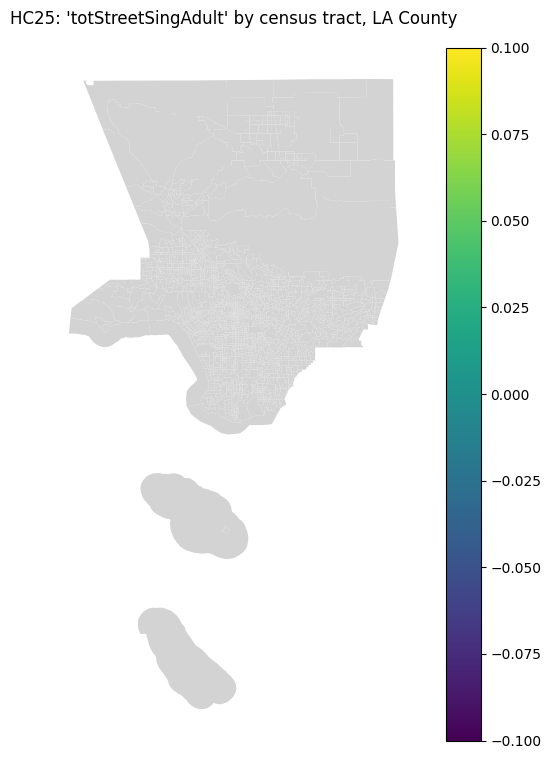

In [ ]:
gdf = gdf.to_crs(3857)                                  # Web-Mercator projection (L22)
ax = gdf.plot(column=COUNT_COLS[0], legend=True, figsize=(8, 9),
              missing_kwds={"color": "lightgrey"})
ax.set_axis_off()
ax.set_title(f"HC25: '{COUNT_COLS[0]}' by census tract, LA County")

# plotly-express alternative (grammar-of-graphics consistent), uncomment to use:
# gj = gdf.to_crs(4326).__geo_interface__
# px.choropleth_mapbox(gdf.to_crs(4326), geojson=gj, locations=gdf.index,
#                      color=COUNT_COLS[0], mapbox_style="carto-positron",
#                      center={"lat":34.0,"lon":-118.2}, zoom=8, opacity=0.6).show()

In [ ]:
df.to_csv("hc25_tract_clean_wide.csv", index=False)
tidy.to_csv("hc25_tract_clean_tidy.csv", index=False)
gdf.drop(columns="geometry").to_csv("hc25_tract_geo_attributes.csv", index=False)
print("Saved: hc25_tract_clean_wide.csv, hc25_tract_clean_tidy.csv, hc25_tract_geo_attributes.csv")

Saved: hc25_tract_clean_wide.csv, hc25_tract_clean_tidy.csv, hc25_tract_geo_attributes.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
for f in ["hc25_tract_clean_wide.csv", "hc25_tract_clean_tidy.csv", "hc25_tract_geo_attributes.csv"]:
    shutil.copy(f, f"/content/drive/MyDrive/{f}")
print("Copied to Drive")


Mounted at /content/drive
Copied to Drive
